In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load Data
# -----------------------------
events = pd.read_csv("events.csv")
ratings = pd.read_csv("user_ratings.csv")

print("✅ Data Loaded Successfully")
print("\n--- Events Sample ---")
print(events.head())
print("\n--- Ratings Sample ---")
print(ratings.head())

✅ Data Loaded Successfully

--- Events Sample ---
   event_id         event_name   category  \
0         1      Music Event 1      music   
1         2    Startup Event 2    startup   
2         3  Hackathon Event 3  hackathon   
3         4  Hackathon Event 4  hackathon   
4         5        Art Event 5        art   

                                         description  \
0  A great music event featuring experts, fun, an...   
1  A great startup event featuring experts, fun, ...   
2  A great hackathon event featuring experts, fun...   
3  A great hackathon event featuring experts, fun...   
4  A great art event featuring experts, fun, and ...   

                                   tags location  duration_hours  
0      music, fun, networking, learning   Mumbai               3  
1    startup, fun, networking, learning     Pune               5  
2  hackathon, fun, networking, learning     Pune               2  
3  hackathon, fun, networking, learning     Pune               6  
4      

In [3]:
print("\n--- Events Info ---")
print(events.info())
print("\n--- Ratings Info ---")
print(ratings.info())



--- Events Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   event_id        30 non-null     int64 
 1   event_name      30 non-null     object
 2   category        30 non-null     object
 3   description     30 non-null     object
 4   tags            30 non-null     object
 5   location        30 non-null     object
 6   duration_hours  30 non-null     int64 
dtypes: int64(2), object(5)
memory usage: 1.8+ KB
None

--- Ratings Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   user_id   990 non-null    int64
 1   event_id  990 non-null    int64
 2   rating    990 non-null    int64
dtypes: int64(3)
memory usage: 23.3 KB
None


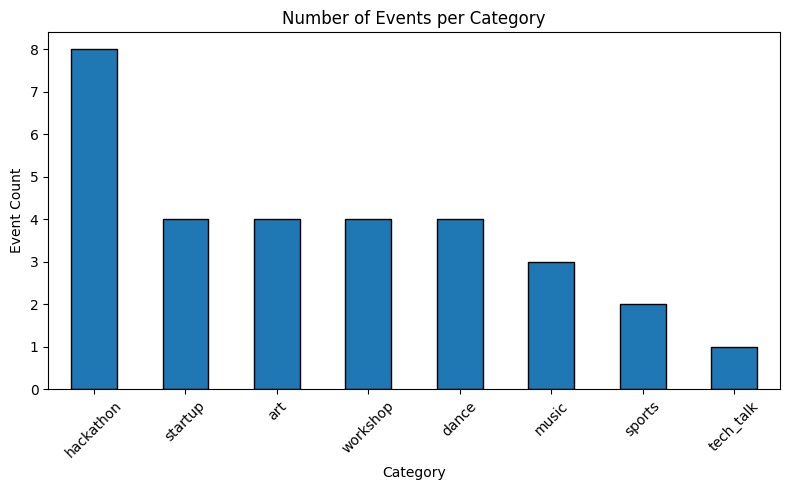

In [4]:
plt.figure(figsize=(8, 5))
events["category"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Number of Events per Category")
plt.xlabel("Category")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

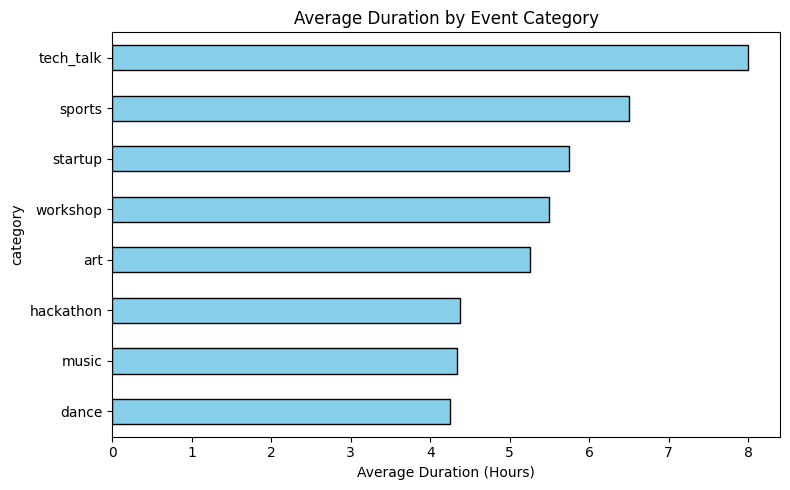

In [5]:
avg_duration = events.groupby("category")["duration_hours"].mean().sort_values()
plt.figure(figsize=(8, 5))
avg_duration.plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Average Duration by Event Category")
plt.xlabel("Average Duration (Hours)")
plt.tight_layout()
plt.show()

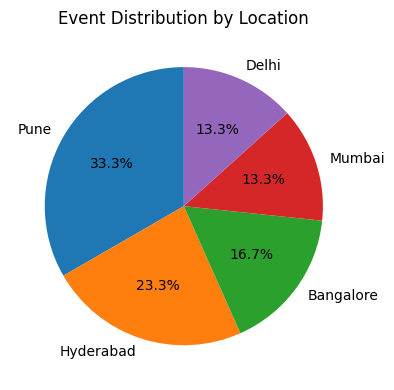

In [6]:
plt.figure(figsize=(6, 4))
events["location"].value_counts().plot(kind="pie", autopct='%1.1f%%', startangle=90)
plt.title("Event Distribution by Location")
plt.ylabel("")
plt.tight_layout()
plt.show()

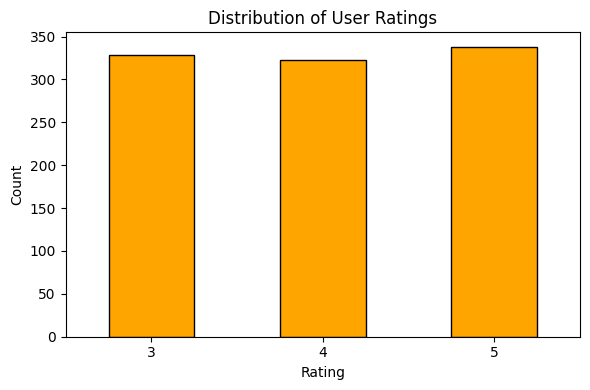

In [7]:
plt.figure(figsize=(6, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="orange", edgecolor="black")
plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

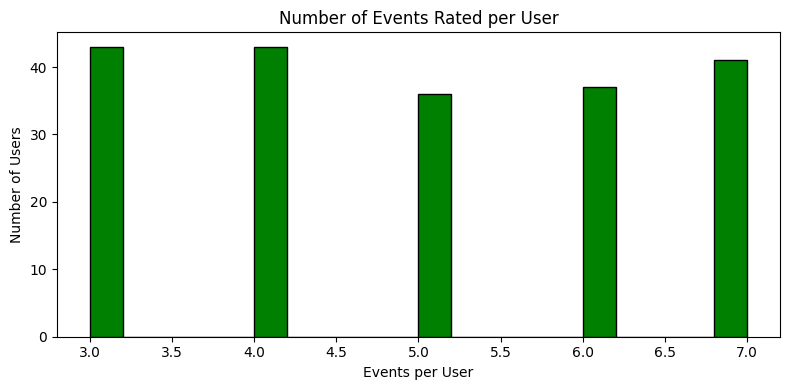

In [8]:
user_activity = ratings["user_id"].value_counts()
plt.figure(figsize=(8, 4))
plt.hist(user_activity, bins=20, color="green", edgecolor="black")
plt.title("Number of Events Rated per User")
plt.xlabel("Events per User")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


MODEL Training


In [9]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Load Data
# -----------------------------
events = pd.read_csv("events.csv")
ratings = pd.read_csv("user_ratings.csv")

print("✅ Data Loaded: ", events.shape, ratings.shape)

✅ Data Loaded:  (30, 7) (990, 3)


In [10]:
events["combined_text"] = (
    events["category"].fillna('') + " " +
    events["description"].fillna('') + " " +
    events["tags"].fillna('')
)

In [11]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(events["combined_text"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("✅ TF-IDF Matrix Shape:", tfidf_matrix.shape)

✅ TF-IDF Matrix Shape: (30, 15)


In [12]:
event_indices = pd.Series(events.index, index=events["event_id"]).drop_duplicates()


In [13]:
def recommend_similar_events(event_id, top_n=5):
    if event_id not in event_indices:
        print("⚠️ Invalid event_id")
        return []
    idx = event_indices[event_id]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]  # Skip itself
    similar_indices = [i[0] for i in sim_scores]
    return events.iloc[similar_indices][["event_id", "event_name", "category", "location"]]


In [14]:
def recommend_for_user(user_id, top_n=5):
    user_data = ratings[ratings["user_id"] == user_id]
    if user_data.empty:
        print("⚠️ No data for this user.")
        return []
    # Choose highest-rated event as reference
    top_event_id = user_data.sort_values("rating", ascending=False).iloc[0]["event_id"]
    return recommend_similar_events(top_event_id, top_n)

In [15]:
user_id = 10  # You can change this
print(f"\n🎯 Recommendations for User {user_id}:\n")
recommendations = recommend_for_user(user_id, top_n=5)
print(recommendations)


🎯 Recommendations for User 10:

    event_id          event_name   category   location
23        24     Sports Event 24     sports  Bangalore
2          3   Hackathon Event 3  hackathon       Pune
3          4   Hackathon Event 4  hackathon       Pune
10        11  Hackathon Event 11  hackathon      Delhi
11        12  Hackathon Event 12  hackathon  Bangalore


In [16]:
events["combined_text"] = (
    events["category"].fillna('') + " " +
    events["description"].fillna('') + " " +
    events["tags"].fillna('')
)

In [17]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(events["combined_text"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [18]:
model_data = {
    "tfidf": tfidf,
    "cosine_sim": cosine_sim,
    "events": events
}

In [20]:
import pickle

with open("event_recommender.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [21]:
with open("event_recommender.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [22]:
import pandas as pd
import pickle
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Load Trained Model
# -----------------------------
with open("event_recommender.pkl", "rb") as f:
    model_data = pickle.load(f)

tfidf = model_data["tfidf"]
cosine_sim = model_data["cosine_sim"]
events = model_data["events"]

print("✅ Model loaded successfully")

# -----------------------------
# 2. Helper Functions
# -----------------------------
def get_event_index(event_id):
    """Return DataFrame index for given event_id"""
    row = events[events["event_id"] == event_id]
    if row.empty:
        return None
    return row.index[0]

def recommend_similar_events(event_id, top_n=5):
    """Recommend similar events to one event"""
    idx = get_event_index(event_id)
    if idx is None:
        print(f"⚠️ Event ID {event_id} not found.")
        return pd.DataFrame()
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]
    similar_indices = [i[0] for i in sim_scores]
    return events.iloc[similar_indices][["event_id", "event_name", "category", "location"]]

def recommend_for_new_user(liked_event_ids, top_n=5):
    """
    Recommend for a completely new user based on multiple liked events.
    liked_event_ids: list of event IDs the new user liked
    """
    valid_indices = [get_event_index(eid) for eid in liked_event_ids if get_event_index(eid) is not None]
    if not valid_indices:
        print("⚠️ No valid liked events found for the new user.")
        return pd.DataFrame()

    # Compute average similarity scores across liked events
    user_profile_sim = cosine_sim[valid_indices].mean(axis=0)
    sim_scores = list(enumerate(user_profile_sim))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Exclude events the user already liked
    exclude_indices = set(valid_indices)
    recommendations = [i for i in sim_scores if i[0] not in exclude_indices][:top_n]
    recommended_indices = [i[0] for i in recommendations]
    return events.iloc[recommended_indices][["event_id", "event_name", "category", "location"]]

# -----------------------------
# 3. Example Usage
# -----------------------------
# Suppose a completely new user (not in training data)
# likes two events: 5 (Hackathon Event 5) and 12 (Tech Talk Event 12)
new_user_likes = [5, 12]

print(f"\n🧑‍💻 Recommendations for a new user who liked events {new_user_likes}:\n")
recommendations = recommend_for_new_user(new_user_likes, top_n=5)
print(recommendations)

# -----------------------------
# 4. Optional: Save the recommendations
# -----------------------------
recommendations.to_csv("new_user_recommendations.csv", index=False)
print("\n✅ Saved recommendations for new user to new_user_recommendations.csv")


✅ Model loaded successfully

🧑‍💻 Recommendations for a new user who liked events [5, 12]:

    event_id          event_name   category location
2          3   Hackathon Event 3  hackathon     Pune
3          4   Hackathon Event 4  hackathon     Pune
7          8         Art Event 8        art     Pune
10        11  Hackathon Event 11  hackathon    Delhi
16        17        Art Event 17        art   Mumbai

✅ Saved recommendations for new user to new_user_recommendations.csv


In [23]:
import pandas as pd
import pickle
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# 1. Load Model + Data
# -----------------------------
with open("event_recommender.pkl", "rb") as f:
    model_data = pickle.load(f)

events = model_data["events"]
cosine_sim = model_data["cosine_sim"]

ratings = pd.read_csv("user_ratings.csv")

# -----------------------------
# 2. Helper Functions
# -----------------------------
def get_event_index(event_id):
    row = events[events["event_id"] == event_id]
    if row.empty:
        return None
    return row.index[0]

def recommend_events(event_id, top_n=5):
    idx = get_event_index(event_id)
    if idx is None:
        return []
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    return [events.iloc[i[0]]["event_id"] for i in sim_scores[1:top_n+1]]

# -----------------------------
# 3. Evaluate Precision@5
# -----------------------------
users = ratings["user_id"].unique()
precisions = []

for user in users:
    user_rated = ratings[ratings["user_id"] == user]
    liked = user_rated[user_rated["rating"] >= 4]["event_id"].tolist()

    if not liked:
        continue

    # Pick one liked event as seed
    base_event = liked[0]
    recs = recommend_events(base_event, top_n=5)
    # Check overlap
    hits = len(set(recs) & set(liked))
    precision = hits / 5.0
    precisions.append(precision)

if precisions:
    avg_precision = np.mean(precisions)
    print(f"🎯 Average Precision@5 across users: {avg_precision:.3f}")
else:
    print("⚠️ Not enough data to evaluate.")


🎯 Average Precision@5 across users: 0.205


In [26]:
import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Load the Realistic Dataset
# -----------------------------
events = pd.read_csv("realistic_events.csv")
ratings = pd.read_csv("realistic_user_ratings.csv")

print(f"✅ Loaded {len(events)} events and {len(ratings)} user ratings")

# -----------------------------
# 2. Combine Text Features for Each Event
# -----------------------------
events["combined_features"] = (
    events["category"].fillna("") + " " +
    events["description"].fillna("") + " " +
    events["tags"].fillna("")
)

# -----------------------------
# 3. Vectorize Text using TF-IDF
# -----------------------------
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(events["combined_features"])

# -----------------------------
# 4. Compute Cosine Similarity between Events
# -----------------------------
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("📊 Cosine similarity matrix shape:", cosine_sim.shape)

# -----------------------------
# 5. Save the Model as .pkl
# -----------------------------
model_data = {
    "tfidf": tfidf,
    "cosine_sim": cosine_sim,
    "events": events
}

model_path = "model/event_recommender.pkl"
import os
os.makedirs("model", exist_ok=True)

with open(model_path, "wb") as f:
    pickle.dump(model_data, f)

print(f"✅ Model trained and saved successfully at: {model_path}")


✅ Loaded 50 events and 1600 user ratings
📊 Cosine similarity matrix shape: (50, 50)
✅ Model trained and saved successfully at: model/event_recommender.pkl


In [27]:
import pandas as pd
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Load Model + Dataset
# -----------------------------
with open("model/event_recommender.pkl", "rb") as f:
    model_data = pickle.load(f)

events = model_data["events"]
cosine_sim = model_data["cosine_sim"]

ratings = pd.read_csv("realistic_user_ratings.csv")

print(f"✅ Loaded model with {len(events)} events and {len(ratings)} user ratings")

# -----------------------------
# 2. Helper Functions
# -----------------------------
def get_event_index(event_id):
    row = events[events["event_id"] == event_id]
    if row.empty:
        return None
    return row.index[0]

def recommend_events(event_id, top_n=5):
    idx = get_event_index(event_id)
    if idx is None:
        return []
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    return [events.iloc[i[0]]["event_id"] for i in sim_scores[1:top_n+1]]

# -----------------------------
# 3. Evaluate Precision@5
# -----------------------------
users = ratings["user_id"].unique()
precisions = []

for user in users:
    user_rated = ratings[ratings["user_id"] == user]
    liked = user_rated[user_rated["rating"] >= 4]["event_id"].tolist()

    if len(liked) < 2:
        continue  # Skip users with too few liked events

    # Pick one liked event as the "seed"
    base_event = liked[0]
    recs = recommend_events(base_event, top_n=5)

    # Count how many recommended events were also liked
    hits = len(set(recs) & set(liked))
    precision = hits / 5.0
    precisions.append(precision)

if precisions:
    avg_precision = np.mean(precisions)
    print(f"🎯 Average Precision@5: {avg_precision:.3f}")
else:
    print("⚠️ Not enough data to evaluate.")


✅ Loaded model with 50 events and 1600 user ratings
🎯 Average Precision@5: 0.470
